In [9]:
import os

from distribution import hidden_layer_1_size, train_losses, batch_losses_train, batch_accs_train

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import tempfile
matplotlib.rcParams['figure.figsize'] = (9, 6)
tf.random.set_seed(22)

In [6]:
train_data, val_data, test_data = tfds.load("mnist", split=['train[10000:]', 'train[0:10000]', 'test'],
                                            batch_size=128, as_supervised=True)

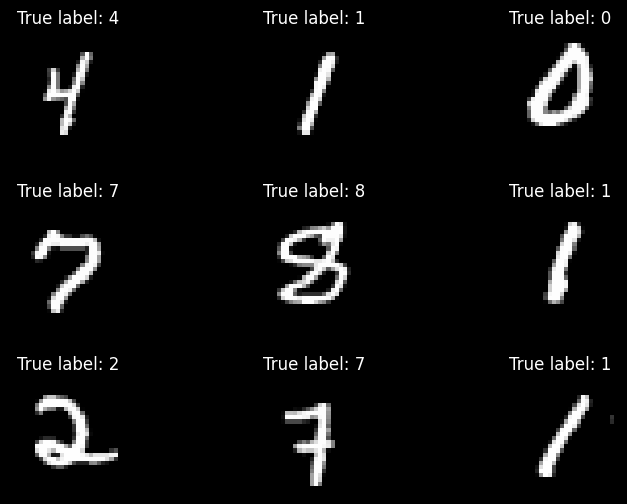

In [7]:
x_viz, y_viz = tfds.load("mnist", split=['train[:1500]'], batch_size=-1, as_supervised=True)[0]
x_viz = tf.squeeze(x_viz, axis=3)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.axis('off')
    plt.imshow(x_viz[i], cmap='gray')
    plt.title(f"True label: {y_viz[i]}")
    plt.subplots_adjust(hspace=0.5)

Text(0.5, 1.0, 'MNIST Digits distribution')

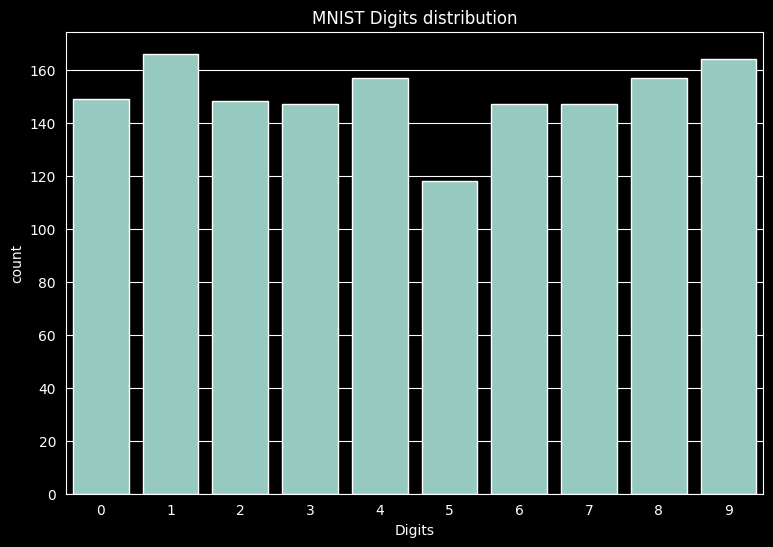

In [10]:
sns.countplot(x=y_viz.numpy())
plt.xlabel("Digits")
plt.title("MNIST Digits distribution")

In [11]:
def preprocess(x, y):
    x = tf.reshape(x, shape=[-1, 784])
    x = x / 255
    return x, y


train_data, val_data = train_data.map(preprocess), val_data.map(preprocess)

Text(0.5, 1.0, 'ReLU activation function')

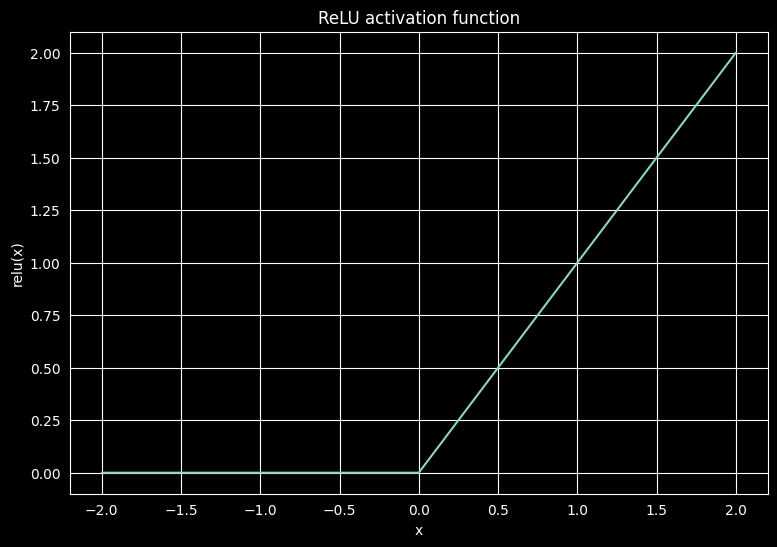

In [12]:
x = tf.linspace(-2, 2, 201)
x = tf.cast(x, tf.float32)
plt.plot(x, tf.nn.relu(x))
plt.xlabel("x")
plt.ylabel("relu(x)")
plt.title("ReLU activation function")

Text(0.5, 1.0, 'Softmax activation function')

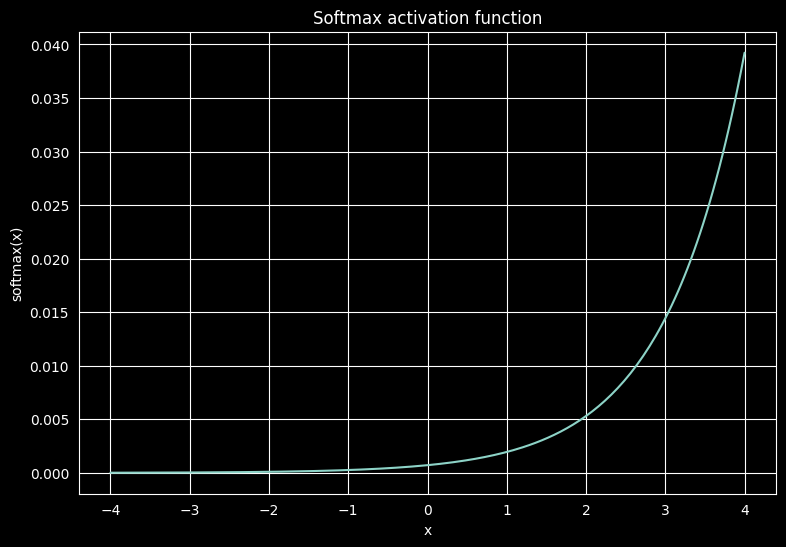

In [13]:
x = tf.linspace(-4, 4, 201)
x = tf.cast(x, tf.float32)
plt.plot(x, tf.nn.softmax(x))
plt.xlabel("x")
plt.ylabel("softmax(x)")
plt.title("Softmax activation function")

In [14]:
def xavier_init(shape):
    in_dim, out_dim = shape
    xavier_lim = tf.sqrt(6.) / tf.sqrt(tf.cast(in_dim + out_dim, tf.float32))
    weight_vals = tf.random.uniform(shape, minval=-xavier_lim, maxval=xavier_lim, seed=22)
    return weight_vals

In [15]:
class DenseLayer(tf.Module):
    def __init__(self, out_dim, weight_init=xavier_init, activation=tf.identity):
        super().__init__()

        self.out_dim = out_dim
        self.weight_init = weight_init
        self.activation = activation
        self.built = False

    def __call__(self, x):
        if not self.built:
            self.in_dim = x.shape[1]
            self.w = tf.Variable(self.weight_init(shape=(self.in_dim, self.out_dim)))
            self.b = tf.Variable(tf.zeros(shape=(self.out_dim,)))
            self.built = True
        z = tf.add(tf.matmul(x, self.w), self.b)
        return self.activation(z)

In [16]:
class MLP(tf.Module):
    def __init__(self, layers):
        super().__init__()

        self.layers = layers

    @tf.function
    def __call__(self, x, preds=False):
        for layer in self.layers:
            x = layer(x)
        return x

In [17]:
hidden_layer_1_size = 700
hidden_layer_2_size = 500
output_size = 10

mlp_model = MLP([
    DenseLayer(out_dim=hidden_layer_1_size, activation=tf.nn.relu),
    DenseLayer(out_dim=hidden_layer_2_size, activation=tf.nn.relu),
    DenseLayer(out_dim=output_size),
])

In [18]:
def cross_entropy_loss(y_pred, y):
    sparse_ce = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=y_pred)
    return tf.reduce_mean(sparse_ce)

In [19]:
def accuracy(y_pred, y):
    class_preds = tf.argmax(tf.nn.softmax(y_pred), axis=1)
    is_equal = tf.equal(y, class_preds)
    return tf.reduce_mean(tf.cast(is_equal, tf.float32))

In [20]:
class Adam:
    def __init__(self, learning_rate=1e-3, beta_1=0.9, beta_2=0.999, ep=1e-7):
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.learning_rate = learning_rate
        self.ep = ep
        self.t = 1
        self.v_dvar, self.s_dvar = [], []
        self.built = False

    def apply_gradients(self, grads, vars):
        if not self.built:
            for var in vars:
                v = tf.Variable(tf.zeros(shape=var.shape))
                s = tf.Variable(tf.zeros(shape=var.shape))
                self.v_dvar.append(v)
                self.s_dvar.append(s)
            self.built = True
        for i, (d_var, var) in enumerate(zip(grads, vars)):
            self.v_dvar[i].assign(self.beta_1 * self.v_dvar[i] + (1 - self.beta_1) * d_var)
            self.s_dvar[i].assign(self.beta_2 * self.s_dvar[i] + (1 - self.beta_2) * tf.square(d_var))
            v_dbar_bc = self.v_dvar[i] / (1 - (self.beta_1 ** self.t))
            s_dvar_bc = self.s_dvar[i] / (1 - (self.beta_2 ** self.t))
            var.assign_sub(self.learning_rate * (v_dbar_bc / (tf.sqrt(s_dvar_bc) + self.ep)))
        self.t += 1
        return

In [25]:
def train_step(x_batch, y_batch, loss, acc, model, optimizer):
    with tf.GradientTape() as tape:
        y_pred = model(x_batch)
        batch_loss = loss(y_pred, y_batch)
    batch_acc = acc(y_pred, y_batch)
    grads = tape.gradient(batch_loss, model.variables)
    optimizer.apply_gradients(grads, model.variables)
    return batch_loss, batch_acc


def val_step(x_batch, y_batch, loss, acc, model):
    y_pred = model(x_batch)
    batch_loss = loss(y_pred, y_batch)
    batch_acc = acc(y_pred, y_batch)
    return batch_loss, batch_acc


def train_model(mlp, train_data, val_data, epochs, loss, acc, optimizer):
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(epochs):
        batch_losses_train, batch_accs_train = [], []
        batch_losees_val, batch_accs_val = [], []
        for x_batch, y_batch in train_data:
            batch_loss, batch_acc = train_step(x_batch, y_batch, loss, acc, mlp, optimizer)
            batch_losses_train.append(batch_loss)
            batch_accs_train.append(batch_acc)
        for x_batch, y_batch in val_data:
            batch_loss, batch_acc = val_step(x_batch, y_batch, loss, acc, mlp)
            batch_losees_val.append(batch_loss)
            batch_accs_val.append(batch_acc)
        train_loss, train_acc = tf.reduce_mean(batch_losses_train), tf.reduce_mean(batch_accs_train)
        val_loss, val_acc = tf.reduce_mean(batch_losees_val), tf.reduce_mean(batch_accs_val)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"Epoch: {epoch}")
        print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")
        print(f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")
    return train_losses, train_accs, val_losses, val_accs

In [26]:
train_losses, train_accs, val_losses, val_accs = train_model(mlp_model, train_data, val_data,
                                                             loss=cross_entropy_loss, acc=accuracy,
                                                             optimizer=Adam(), epochs=10)

Epoch: 0
Train loss: 0.0104, Train acc: 0.9971
Val loss: 0.1541, Val acc: 0.9785
Epoch: 1
Train loss: 0.0087, Train acc: 0.9971
Val loss: 0.1272, Val acc: 0.9810
Epoch: 2
Train loss: 0.0052, Train acc: 0.9985
Val loss: 0.1250, Val acc: 0.9832
Epoch: 3
Train loss: 0.0058, Train acc: 0.9983
Val loss: 0.1294, Val acc: 0.9822
Epoch: 4
Train loss: 0.0075, Train acc: 0.9976
Val loss: 0.1253, Val acc: 0.9829
Epoch: 5
Train loss: 0.0080, Train acc: 0.9976
Val loss: 0.1550, Val acc: 0.9796
Epoch: 6
Train loss: 0.0075, Train acc: 0.9976
Val loss: 0.1465, Val acc: 0.9815
Epoch: 7
Train loss: 0.0080, Train acc: 0.9978
Val loss: 0.1361, Val acc: 0.9806
Epoch: 8
Train loss: 0.0054, Train acc: 0.9984
Val loss: 0.1409, Val acc: 0.9794
Epoch: 9
Train loss: 0.0069, Train acc: 0.9981
Val loss: 0.1233, Val acc: 0.9834


In [27]:
def plot_metric(train_metric, val_metric, metric_type):
    plt.figure()
    plt.plot(range(len(train_metric)), train_metric, label=f"Trainining {metric_type}")
    plt.plot(range(len(val_metric)), val_metric, label=f"Validation {metric_type}")
    plt.xlabel("Epochs")
    plt.ylabel(metric_type)
    plt.legend()
    plt.title(f"{metric_type} vs training epochs")

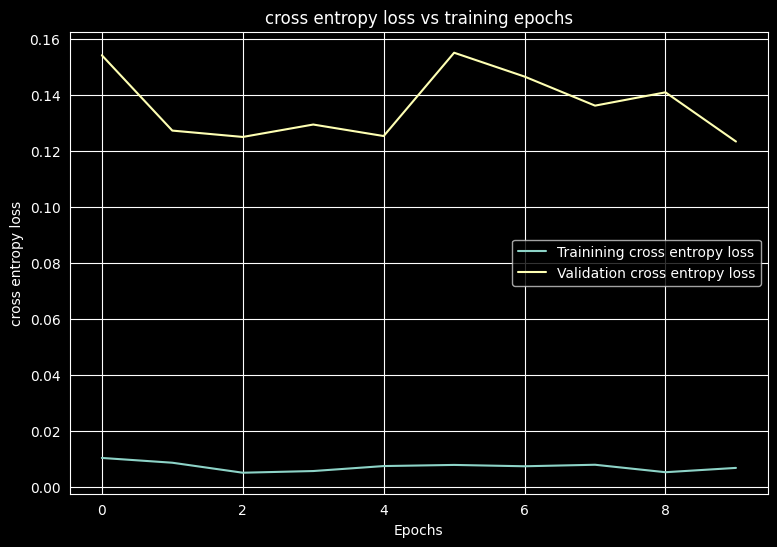

In [28]:
plot_metric(train_losses, val_losses, "cross entropy loss")

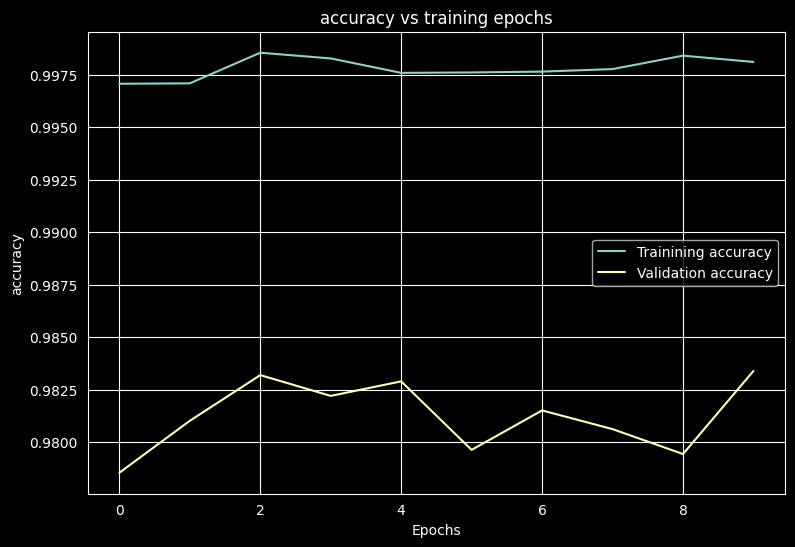

In [30]:
plot_metric(train_accs, val_accs, "accuracy")